# <center> **Anomalies Detection using Isolation Forest** </center>
----

### Imports

In [18]:
import pandas as pd 
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

### Load the data

In [3]:
df = pd.read_csv("thyroid_dataset.csv")
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


### Shape of the data

In [6]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 6916
Number of columns: 22


### Basic information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6916 entries, 0 to 6915
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        6916 non-null   float64
 1   Sex                        6916 non-null   int64  
 2   on_thyroxine               6916 non-null   int64  
 3   query_on_thyroxine         6916 non-null   int64  
 4   on_antithyroid_medication  6916 non-null   int64  
 5   sick                       6916 non-null   int64  
 6   pregnant                   6916 non-null   int64  
 7   thyroid_surgery            6916 non-null   int64  
 8   I131_treatment             6916 non-null   int64  
 9   query_hypothyroid          6916 non-null   int64  
 10  query_hyperthyroid         6916 non-null   int64  
 11  lithium                    6916 non-null   int64  
 12  goitre                     6916 non-null   int64  
 13  tumor                      6916 non-null   int64

### Statistical Summary

In [8]:
df.describe()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,lithium,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured
count,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,...,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000
mean,0.595098,0.307548,0.134615,0.015616,0.013158,0.038317,0.011278,0.014315,0.016773,0.062753,...,0.013013,0.008531,0.025448,0.000145,0.049740,1.603466,11.772446,94.253834,88.270139,95.257058
std,6.189326,0.461512,0.341337,0.123993,0.113959,0.191974,0.105606,0.118793,0.128428,0.242536,...,0.113339,0.091975,0.157494,0.012025,0.217422,14.047218,11.836250,50.555642,33.909845,55.031137
min,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000500,0.002500,0.050000,0.002400
25%,0.370000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000680,0.020100,77.000000,83.000000,81.000000
50%,0.540000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.001700,13.000000,101.000000,96.000000,105.000000
75%,0.670000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.002700,22.000000,123.000000,104.000000,125.000000
max,515.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,494.000000,95.000000,395.000000,233.000000,642.000000


### Null values

In [9]:
df.isnull().sum()

Age                          0
Sex                          0
on_thyroxine                 0
query_on_thyroxine           0
on_antithyroid_medication    0
sick                         0
pregnant                     0
thyroid_surgery              0
I131_treatment               0
query_hypothyroid            0
query_hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH                          0
T3_measured                  0
TT4_measured                 0
T4U_measured                 0
FTI_measured                 0
Outlier_label                0
dtype: int64

### Separate Features and Target

In [10]:
X = df.drop("Outlier_label", axis=1)

# Target labels
y = df["Outlier_label"]

### Sandardize the Data

- Most anomaly detection algorithms perform better when features are on the same scale.

In [13]:
# Create scaler
scaler = StandardScaler()

# Scale features
X_scaled = scaler.fit_transform(X)

### Apply Isolation Forest

In [15]:
# Create Isolation Forest model
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.036,
    random_state=42
)

# Train model and predict
iso_labels = iso_forest.fit_predict(X_scaled)

**Isolation Forest returns:**

- `1` → Normal Observation

- `-1` → Outlier

### Count predictions

In [16]:
n_outliers = np.sum(iso_labels == -1)
n_normal = np.sum(iso_labels == 1)

print("Outliers:", n_outliers)
print("Normal:", n_normal)

Outliers: 249
Normal: 6667


### Anomaly Scores

- Isolation Forest assigns an anomaly score to every observation.

- More negative values indicate stronger anomalies.

In [17]:
# Anomaly scores
scores = iso_forest.decision_function(X_scaled)

print(scores[:10])

[ 0.04722209  0.04389765 -0.01835957  0.03004467  0.04750114 -0.04917208
  0.01170897 -0.01120305  0.05136676  0.02755077]


### PCA for Visualization

- The dataset may contain many dimensions.

- PCA reduces dimensions to 2 so that we can visualize observations on a 2D plot.

- This visualization is only for interpretation and does not affect model training.

In [19]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

### Visualizing Isolation Forest Results

- Yellow and purple regions represent different prediction classes.

- Points labeled -1 are detected anomalies.

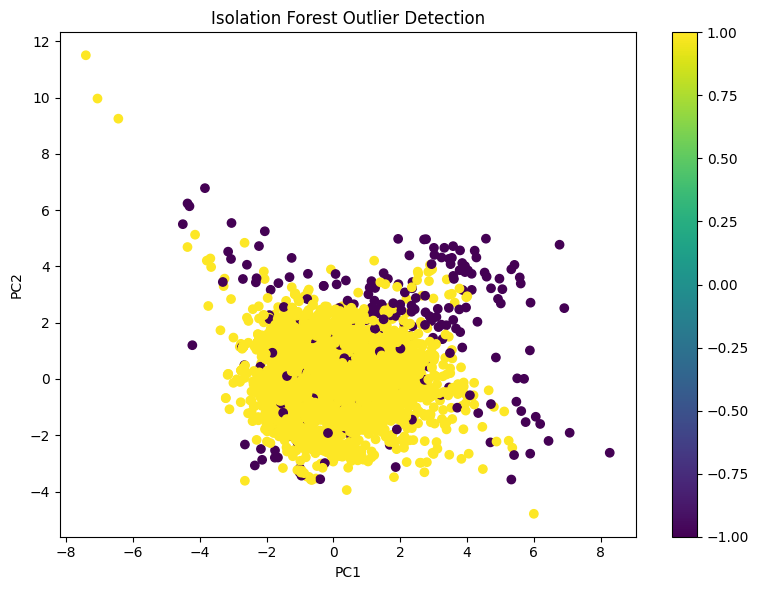

In [20]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=iso_labels,
    cmap="viridis"
)

plt.colorbar(scatter)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Isolation Forest Outlier Detection")

plt.tight_layout()
plt.show()

### Conclusion

**In this notebook we:**

- Loaded the Thyroid dataset
- Standardized the features
- Applied Isolation Forest
- Detected anomalies
- Visualized results using PCA
